In [1]:
from collections import deque
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'brain.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img.shape

(256, 256)

In [3]:
def region_grow(image, seed, threshold):
    N, M = image.shape
    seed_value = int(image[seed])
    mask = np.zeros((N, M), dtype=np.uint8)
    mask[seed] = 255
    queue = deque([seed])

    while queue:
        y, x = queue.popleft()
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                ny, nx = y + dy, x + dx
                if 0 <= ny < N and 0 <= nx < M and mask[ny, nx] == 0:
                    if abs(int(image[ny, nx]) - seed_value) <= threshold:
                        mask[ny, nx] = 255
                        queue.append((ny, nx))
    return mask

seed=(130, 90), threshold=5 - region size: 790
seed=(130, 90), threshold=15 - region size: 6371
seed=(130, 90), threshold=30 - region size: 22293
seed=(110, 185), threshold=5 - region size: 5071


seed=(110, 185), threshold=15 - region size: 15050
seed=(110, 185), threshold=30 - region size: 22141


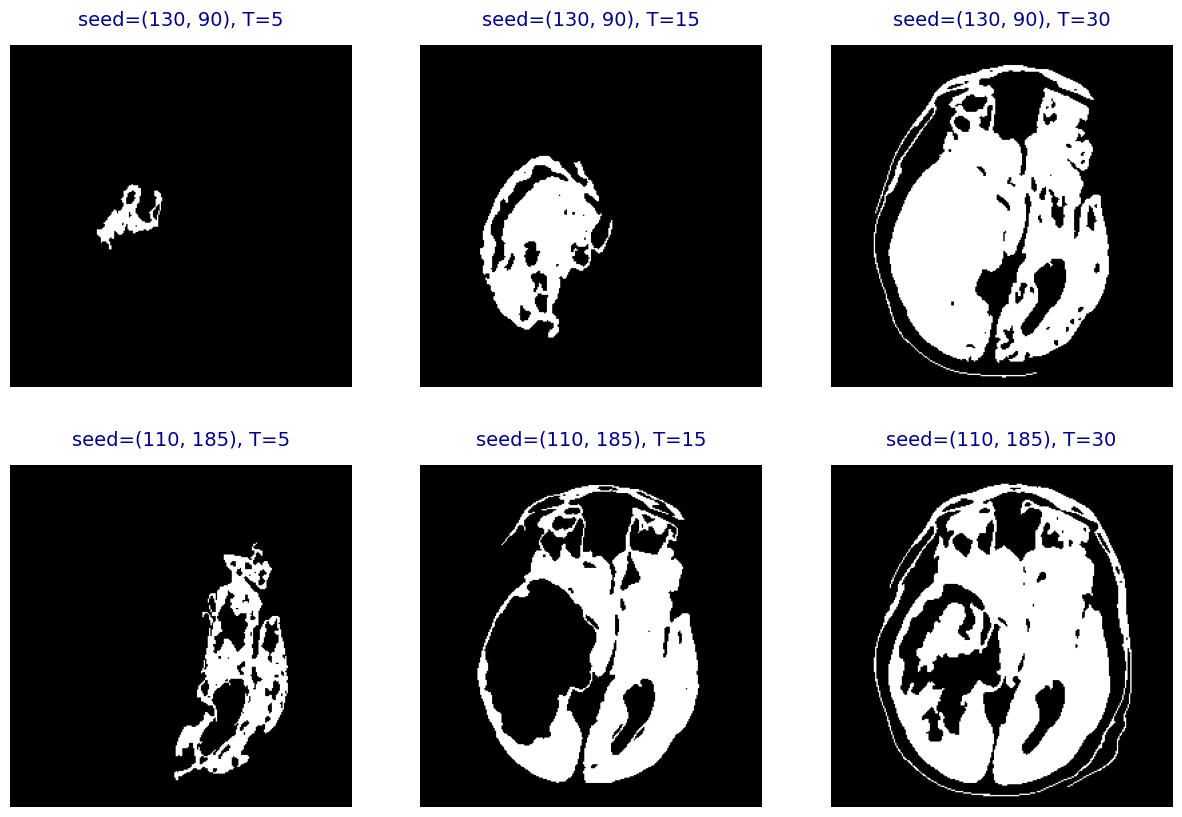

In [4]:
blurred = cv2.GaussianBlur(img, (5, 5), 0)

N, M = img.shape
seeds = [(130, 90), (110, 185)]
thresholds = [5, 15, 30]

panels = []
for seed in seeds:
    for t in thresholds:
        mask = region_grow(blurred, seed, t)
        print(f'seed={seed}, threshold={t} - region size:', cv2.countNonZero(mask))
        panels.append((f'seed={seed}, T={t}', mask))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

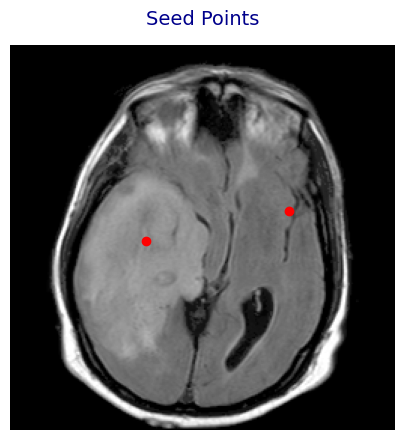

In [5]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(img, cmap='gray')
for y, x in seeds:
    plt.plot(x, y, 'r.', markersize=12)
plt.title('Seed Points', fontsize=14, color='darkblue', pad=15)
plt.show()

In [6]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task6_region.png', region_grow(blurred, seeds[0], 15))

True

Region sizes from seed (130, 90) on the bright left side: 790, 6371, 22293 for thresholds 5, 15, 30. From seed (110, 185) on the right side: 5071, 15050, 22141.

A small threshold gives a patchy region. T=15 follows the bright area on the left. T=30 leaks out into most of the brain and part of the skull.

Why can changing the seed change the region a lot? Pixels are compared with the seed's intensity. A seed in the bright area only accepts similar bright pixels, a seed on the right side only accepts pixels close to its own darker value. So the same threshold grows two different regions. A noisy seed pixel also shifts the reference value.